# reviews EDA + feature engineering

this notebook walks through the reviews pipeline — cleaning, structural features, and sentiment scoring. the actual code is in the `reviews/` module. here we just run it step by step and look at the results.

In [1]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r'c:\Users\Anwender\Documents\AirBnB-price-predictor'
os.chdir(PROJECT_ROOT)

RAW_AVAIL = os.path.exists('data/reviews.csv')
if not RAW_AVAIL:
    print("note: data/reviews.csv not present locally — sections 1-4 will skip")
    print("      sections 5-6 load from data/reviews_features.csv (present)")


note: data/reviews.csv not present locally — sections 1-4 will skip
      sections 5-6 load from data/reviews_features.csv (present)


## 1. raw data

In [2]:
if RAW_AVAIL:
    reviews = pd.read_csv('data/reviews.csv')
    print(reviews.shape)
    display(reviews.head())
else:
    reviews = None
    print("skipped — raw data not available locally")


skipped — raw data not available locally


In [3]:
if reviews is not None:
    per_listing = reviews.groupby('listing_id').size()
    print('unique listings:', len(per_listing))
    print('avg reviews per listing:', per_listing.mean().round(1))
    print('max:', per_listing.max())
else:
    per_listing = None


In [4]:
if reviews is not None:
    display(reviews['comments'].dropna().sample(10, random_state=7).tolist())


In [5]:
if per_listing is not None:
    fig, ax = plt.subplots(figsize=(8, 3))
    per_listing.clip(upper=250).hist(bins=50, ax=ax, color='#C96B8A', edgecolor='white')
    ax.set_xlabel('number of reviews')
    ax.set_ylabel('listings')
    ax.set_title('reviews per listing (capped at 250)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


## 2. cleaning

the raw comments sometimes have html tags, some are empty after stripping, and some are automated airbnb cancellation messages (not real guest reviews). `clean_reviews.py` handles all of this.

In [6]:
if reviews is not None:
    from reviews.clean_reviews import clean_reviews, clean_comment
    html_ex = reviews[reviews['comments'].str.contains('<', na=False)]['comments'].dropna().iloc[0]
    print('raw:    ', html_ex[:250])
    print()
    print('cleaned:', clean_comment(html_ex)[:250])
else:
    from reviews.clean_reviews import clean_reviews, clean_comment


In [7]:
if reviews is not None:
    reviews_clean = clean_reviews(reviews)
    print(f'before: {len(reviews):,}')
    print(f'after:  {len(reviews_clean):,}')
    print(f'removed: {len(reviews) - len(reviews_clean):,}')
else:
    reviews_clean = None


## 3. structural features

no NLP needed here — just counts and dates. how many reviews, how recent, how fast they come in. fast to compute and works for any language.

In [8]:
from reviews.structural_features import build_structural_features

SNAPSHOT = '2025-09-24'
if reviews_clean is not None:
    struct = build_structural_features(reviews_clean, snapshot_date=SNAPSHOT)
    print(struct.shape)
    display(struct.head())
else:
    struct = None
    print("skipped — raw data not available locally")


skipped — raw data not available locally


In [9]:
if struct is not None:
    display(struct.describe().round(2))


In [10]:
if struct is not None:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))

    struct['rev_n_reviews'].clip(upper=300).hist(bins=50, ax=axes[0], color='#C96B8A', edgecolor='white')
    axes[0].set_title('total reviews (capped 300)')

    struct['rev_per_month'].clip(upper=10).hist(bins=50, ax=axes[1], color='#6B8A40', edgecolor='white')
    axes[1].set_title('reviews per month')

    struct['rev_days_since_last'].hist(bins=50, ax=axes[2], color='#C96B8A', edgecolor='white')
    axes[2].set_title('days since last review')

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


## 4. sentiment analysis

model: `nlptown/bert-base-multilingual-uncased-sentiment` — trained on reviews in EN, NL, DE, FR, ES, IT. outputs an expected star rating (1-5) per review, which we then aggregate per listing.

the demo below only runs on 25 reviews. full run was on google colab (T4 GPU, ~2 hours for 1M reviews).

In [11]:
from reviews.sentiment_features import compute_review_sentiment, build_sentiment_features

if reviews_clean is not None:
    demo = compute_review_sentiment(reviews_clean, sample_n=25, cache_path=None)
    display(demo[['comment_clean', 'sent_stars']].head(10))
else:
    demo = None
    print("skipped — raw data not available locally")
    print("(model: nlptown/bert-base-multilingual-uncased-sentiment, output: 1-5 star float)")


skipped — raw data not available locally
(model: nlptown/bert-base-multilingual-uncased-sentiment, output: 1-5 star float)


In [12]:
if demo is not None:
    for _, row in demo.dropna(subset=['sent_stars']).head(12).iterrows():
        s = round(row['sent_stars'])
        print(f"[{'\u2605'*s}{'\u2606'*(5-s)}]  {str(row['comment_clean'])[:100]}")


In [13]:
if demo is not None:
    sent_feats_demo = build_sentiment_features(demo)
    print(list(sent_feats_demo.columns))
    display(sent_feats_demo.head())


## 5. full output — reviews_features.csv

result of running the full pipeline on all 1M reviews.

In [14]:
feats = pd.read_csv('data/reviews_features.csv')
print(feats.shape)
feats.head()

(11853, 12)


,id,rev_n_reviews,rev_len_chars_mean,rev_len_words_mean,rev_days_since_last,rev_days_since_first,rev_per_month,rev_n_last_year,rev_sent_mean,rev_sent_std,rev_sent_min,rev_frac_negative
0,31840,174,260.408046,45.500000,24,5572,0.954679,41,4.401833,0.503034,1.983227,0.034483
1,32180,42,425.095238,73.809524,66,5578,0.231945,7,4.433143,0.465169,2.639036,0.023810
2,39115,88,292.284091,50.727273,86,5496,0.495142,8,4.409124,0.475478,2.079846,0.022727
3,39165,24,288.208333,51.625000,120,5395,0.138495,2,4.347717,0.555649,2.687324,0.041667
4,39822,37,479.837838,86.567568,23,5490,0.206014,6,4.314080,0.756125,1.303118,0.081081


In [15]:
feats.describe().round(3)

,id,rev_n_reviews,rev_len_chars_mean,rev_len_words_mean,rev_days_since_last,rev_days_since_first,rev_per_month,rev_n_last_year,rev_sent_mean,rev_sent_std,rev_sent_min,rev_frac_negative
count,1.185300e+04,11853.000,11853.000,11853.000,11853.000,11853.000,11853.000,11853.000,11853.000,11853.000,11853.000,11853.000
mean,6.103223e+17,85.096,265.912,45.497,168.868,1447.828,2.215,18.324,4.402,0.475,2.709,0.049
std,5.636250e+17,120.350,106.736,18.917,392.100,1275.078,1.808,20.496,0.321,0.245,1.028,0.104
min,3.184000e+04,1.000,1.000,1.000,1.000,1.000,0.018,0.000,1.035,0.000,1.014,0.000
25%,2.842109e+07,10.000,208.757,35.298,9.000,447.000,0.899,2.000,4.314,0.338,1.881,0.000
50%,7.193097e+17,37.000,254.961,43.583,24.000,937.000,1.762,11.000,4.467,0.467,2.498,0.020
75%,1.136732e+18,108.000,307.705,53.000,109.000,2376.000,3.139,29.000,4.575,0.608,3.536,0.053
max,1.511577e+18,1196.000,2463.000,406.000,4473.000,5578.000,18.561,169.000,4.984,1.871,4.984,1.000


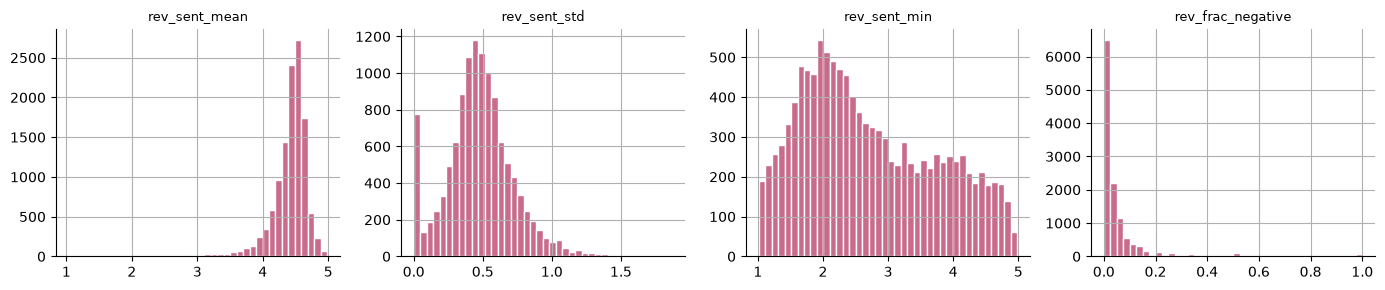

In [16]:
# distributions of sentiment features
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, ['rev_sent_mean', 'rev_sent_std', 'rev_sent_min', 'rev_frac_negative']):
    feats[col].dropna().hist(bins=40, ax=ax, color='#C96B8A', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 6. correlation with price

In [17]:
listings = pd.read_csv('data/listings_features.csv')

price_col = next((c for c in listings.columns if 'price' in c.lower() and 'log' not in c.lower()), None)
if price_col is None:
    price_col = next(c for c in listings.columns if 'price' in c.lower())
print('price column:', price_col)

merged = listings[['id', price_col]].merge(feats, on='id', how='inner')
merged['log_price'] = np.log1p(merged[price_col])
print('shape after merge:', merged.shape)

price column: price
shape after merge: (10874, 14)


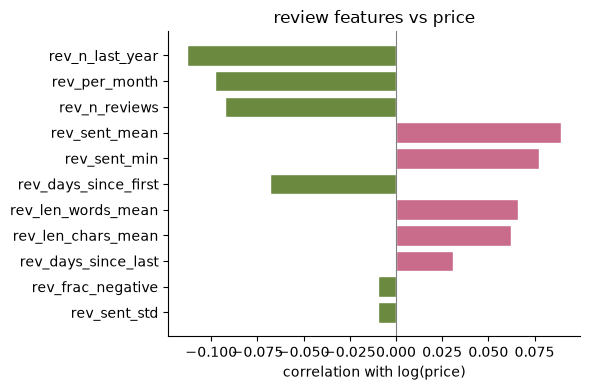

In [18]:
rev_cols = [c for c in feats.columns if c != 'id']
corrs = merged[rev_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values(key=abs)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#C96B8A' if v >= 0 else '#6B8A40' for v in corrs]
ax.barh(corrs.index, corrs.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('correlation with log(price)')
ax.set_title('review features vs price')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

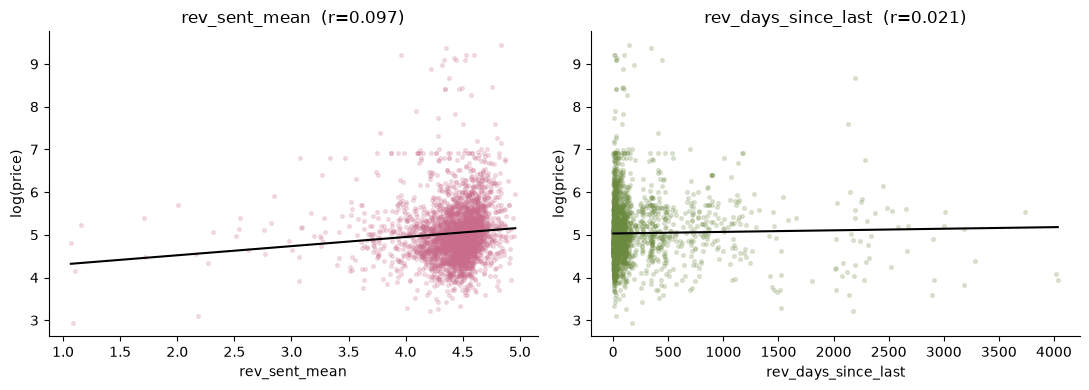

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, color in zip(axes,
    ['rev_sent_mean', 'rev_days_since_last'],
    ['#C96B8A', '#6B8A40']):

    tmp = merged[[col, 'log_price']].dropna().sample(min(3000, len(merged)), random_state=1)
    ax.scatter(tmp[col], tmp['log_price'], alpha=0.2, s=7, color=color)
    m, b = np.polyfit(tmp[col], tmp['log_price'], 1)
    xs = np.linspace(tmp[col].min(), tmp[col].max(), 100)
    ax.plot(xs, m*xs+b, color='black', linewidth=1.5)
    r = tmp[[col, 'log_price']].corr().iloc[0, 1]
    ax.set_title(f'{col}  (r={r:.3f})')
    ax.set_xlabel(col)
    ax.set_ylabel('log(price)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

`rev_sent_mean` and `rev_days_since_last` both have a clear relationship with price — listings with better ratings and more recent reviews tend to be priced higher. in the final model these two features rank #6 and #8 by SHAP importance.